Scenario 1 (Product Ratings):
An e-commerce site claims its average product rating is 4.0 stars. 

You collect a sample of 50 recent ratings from one popular product and want to test whether the product’s average rating differs from 4.0.

Data: product_ratings.csv

In [1]:
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.weightstats import ztest
from scipy.stats import poisson
np.random.seed(42)
import pandas as pd

In [2]:
# Read the data
df_product_ratings =pd.read_csv("../data/product_ratings.csv")

In [3]:
df_product_ratings

,Rating
0,4.519233
1,4.235684
2,4.092176
3,3.999448
4,3.410739
5,3.790078
6,3.919681
7,4.678561
8,4.321809
9,3.268480


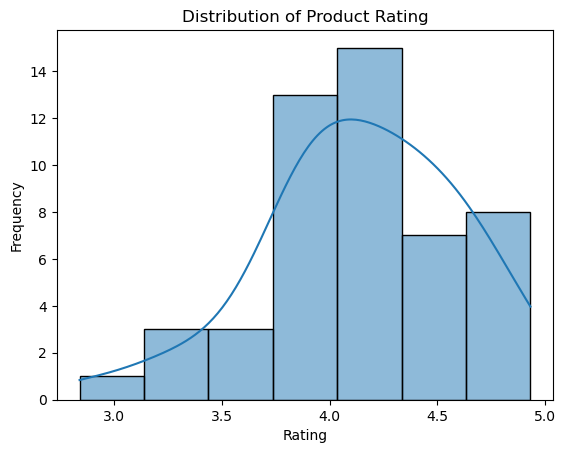

In [4]:
sns.histplot(df_product_ratings['Rating'], kde=True)
plt.title("Distribution of Product Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

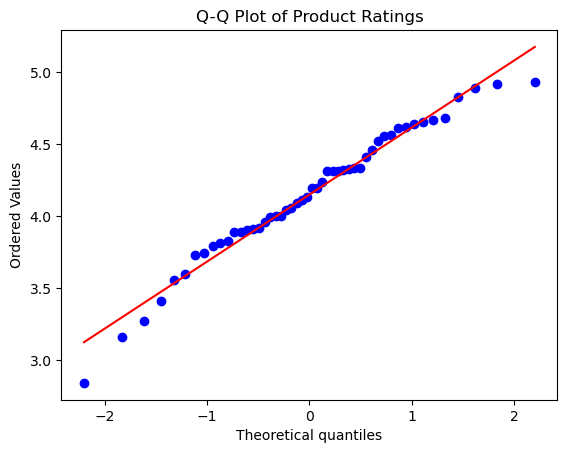

In [5]:
# Q-Q plot
stats.probplot(df_product_ratings['Rating'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Product Ratings")
plt.show()

In [6]:
_, p_value_shapiro = stats.shapiro(df_product_ratings['Rating'])
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")

Shapiro-Wilk p-value: 0.314


In [7]:
# using python built_in function to calculate the ci lower and ci upper
sample_mean = df_product_ratings['Rating'].mean()
sample_std = df_product_ratings['Rating'].std()
sample_median = df_product_ratings['Rating'].median()
n = len(df_product_ratings)

# 95% CI using scipy
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=sample_mean, scale=sample_std/np.sqrt(n))
print(f"Sample Mean: {sample_mean:.2f}")
print(f"95% CI for average temperature: ({ci_lower:.2f}, {ci_upper:.2f})")

Sample Mean: 4.15
95% CI for average temperature: (4.02, 4.28)


In [8]:
# using mathematical formula to calculate the ci lower and ci upper
sample = df_product_ratings['Rating']
mean = sample.mean()
std = sample.std(ddof=1)
n = len(sample)

# 95% CI using t-distribution
t_value = stats.t.ppf(0.975, df=n-1) # The critical t-value for your desired confidence level (from the t-table or software)
margin_error = t_value * (std / np.sqrt(n)) # Margin of Error (ME)=t_value×s/sqrt(n)
ci_lower, ci_upper = mean - margin_error, mean + margin_error

print(f"Sample Mean: {mean:.2f}")
print(f"t critical value: {t_value:.2f}")
print(f"95% CI for daily sales: ({ci_lower:.2f}, {ci_upper:.2f})")

Sample Mean: 4.15
t critical value: 2.01
95% CI for daily sales: (4.02, 4.28)


In [10]:
# Using t-test for sample vs population mean
t_stat, p_value_two = stats.ttest_1samp(df_product_ratings['Rating'], popmean=4, alternative='two-sided')

print(f"Two-tailed t-statistic: {t_stat:.2f}, p-value: {p_value_two:.3f}")

alpha = 0.05

if p_value_two < alpha:
    print("Reject H₀: The average product rating is significantly different from 4.0")
else:
    print("Fail to reject H₀: No significant difference from 4.0")

Two-tailed t-statistic: 2.29, p-value: 0.027
Reject H₀: The average product rating is significantly different from 4.0


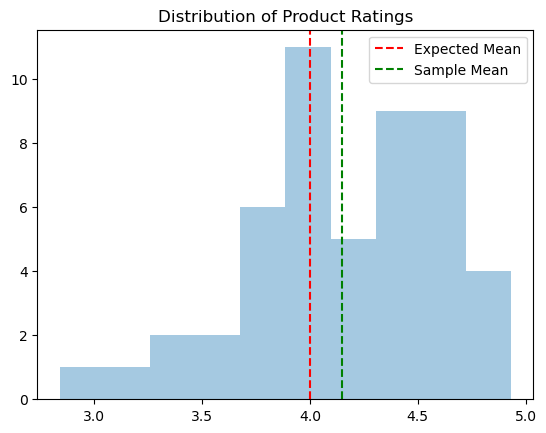

In [13]:
plt.hist(df_product_ratings['Rating'], bins=10, color="#7FB3D5", alpha=0.7)
plt.axvline(4, color='red', linestyle='--', label='Expected Mean')
plt.axvline(df_product_ratings['Rating'].mean(), color='green', linestyle='--', label='Sample Mean')
plt.title("Distribution of Product Ratings")
plt.legend()
plt.show()

Scenario 2  (Checkout Time):
A UX team wants to know the median checkout time (in seconds) for customers on the mobile site. 

Checkout times are typically skewed (some users take a long time). You sample 200 checkout sessions. 

Because the distribution is skewed, you will use bootstrap to compute a 95% CI for the median and test whether the median is less than a target (e.g., 120 seconds).

Data: checkout_times.csv
